In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# EXPLORATION OF DATASET

In [2]:
data = {
    "Source": [
        "P1","P1","P1","P1","P1","P1","P1",
        "P2","P2","P2",
        "P3","P3","P3",
        "P4","P4","P4",
        "P5","P5",
        "P6",
        "P7",
        "P8","P8","P8","P8",
        "P9",
        "P10",
        "P11",
        "P12","P12",
        "P13",
        "P14",
        "P15",
        "P16","P16","P16",
        "P17","P17",
        "P18",
        "P19"
    ],

    "Destination": [
        "P3","P5","P7","P8","P12","P13","P14",
        "P3","P4","P5",
        "P4","P5","P13",
        "P5","P6","P7",
        "P6","P7",
        "P7",
        "P12",
        "P9","P10","P11","P12",
        "P10",
        "P11",
        "P12",
        "P16","P17",
        "P14",
        "P15",
        "P8",
        "P17","P18","P19",
        "P19","P20",
        "P19",
        "P20"
    ]
}

df = pd.DataFrame(data)

df.to_csv("social_network.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [3]:
df = pd.read_csv("social_network.csv")

df.head()

,Source,Destination
0,P1,P3
1,P1,P5
2,P1,P7
3,P1,P8
4,P1,P12


In [4]:
print("Number of connections:", len(df))

print("\nColumn names:")
print(df.columns)

print("\nComplete dataset:")
print(df)

Number of connections: 39

Column names:
Index(['Source', 'Destination'], dtype='object')

Complete dataset:
   Source Destination
0      P1          P3
1      P1          P5
2      P1          P7
3      P1          P8
4      P1         P12
5      P1         P13
6      P1         P14
7      P2          P3
8      P2          P4
9      P2          P5
10     P3          P4
11     P3          P5
12     P3         P13
13     P4          P5
14     P4          P6
15     P4          P7
16     P5          P6
17     P5          P7
18     P6          P7
19     P7         P12
20     P8          P9
21     P8         P10
22     P8         P11
23     P8         P12
24     P9         P10
25    P10         P11
26    P11         P12
27    P12         P16
28    P12         P17
29    P13         P14
30    P14         P15
31    P15          P8
32    P16         P17
33    P16         P18
34    P16         P19
35    P17         P19
36    P17         P20
37    P18         P19
38    P19         P20


In [5]:
G = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Destination"
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 20
Number of edges: 39


The graph

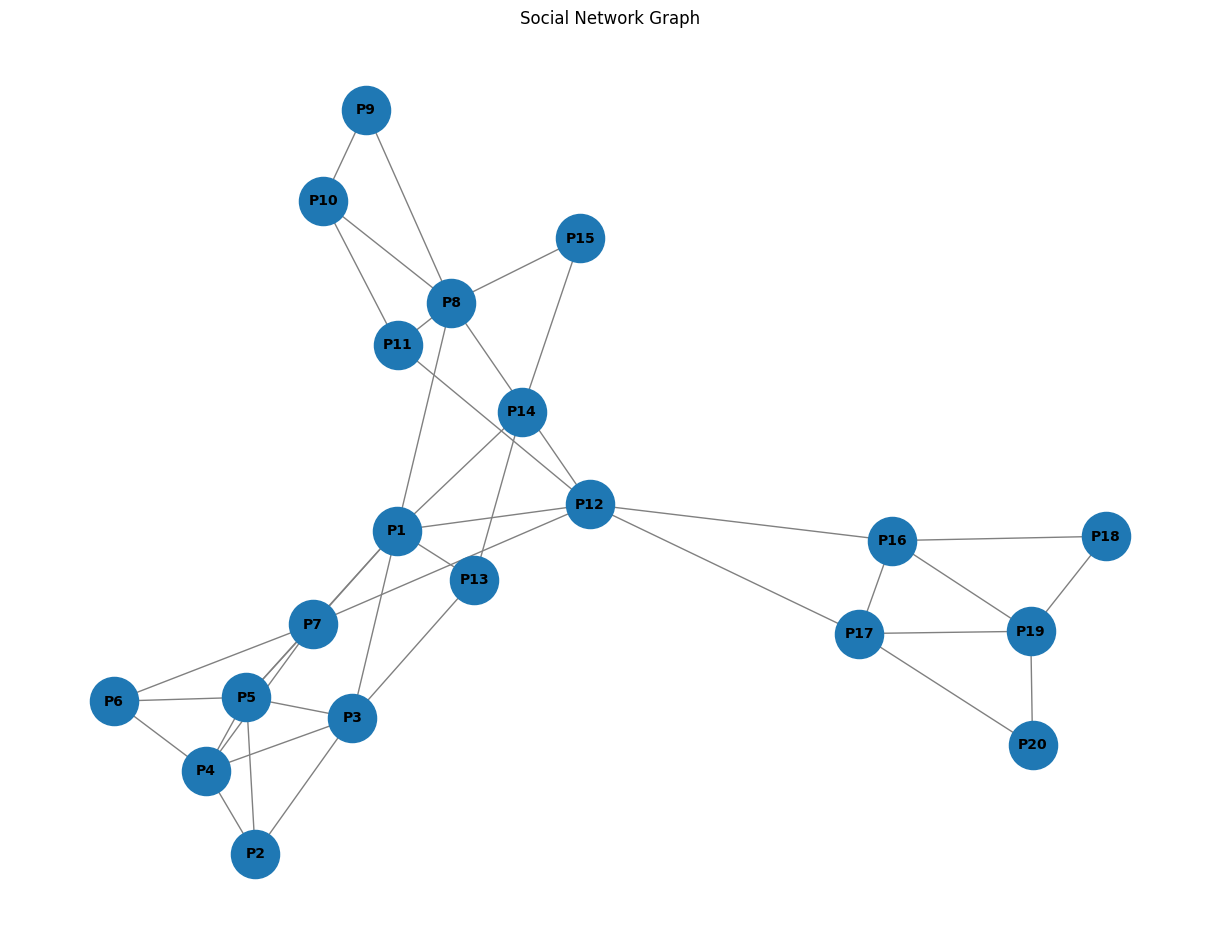

In [6]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Social Network Graph")
plt.show()

In [7]:
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

print("Graph Density:", nx.density(G))

Number of Nodes: 20
Number of Edges: 39
Graph Density: 0.20526315789473684


# DEGREE OF CENTRALITY

In [8]:
degree_centrality = nx.degree_centrality(G)

print("Degree Centrality:\n")

for node, value in degree_centrality.items():
    print(node, ":", round(value, 4))

Degree Centrality:

P1 : 0.3684
P3 : 0.2632
P5 : 0.3158
P7 : 0.2632
P8 : 0.3158
P12 : 0.3158
P13 : 0.1579
P14 : 0.1579
P2 : 0.1579
P4 : 0.2632
P6 : 0.1579
P9 : 0.1053
P10 : 0.1579
P11 : 0.1579
P16 : 0.2105
P17 : 0.2105
P15 : 0.1053
P18 : 0.1053
P19 : 0.2105
P20 : 0.1053


In [9]:
degree_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["Node", "Degree Centrality"]
)

degree_df = degree_df.sort_values(
    by="Degree Centrality",
    ascending=False
)

degree_df

,Node,Degree Centrality
0,P1,0.368421
2,P5,0.315789
5,P12,0.315789
4,P8,0.315789
3,P7,0.263158
1,P3,0.263158
9,P4,0.263158
15,P17,0.210526
14,P16,0.210526
18,P19,0.210526


# BETWEENNESS CENTRALITY

In [10]:
betweenness_centrality = nx.betweenness_centrality(G)

print("Betweenness Centrality:\n")

for node, value in betweenness_centrality.items():
    print(node, ":", round(value, 4))

Betweenness Centrality:

P1 : 0.3433
P3 : 0.0585
P5 : 0.0726
P7 : 0.1588
P8 : 0.2459
P12 : 0.4711
P13 : 0.0102
P14 : 0.0263
P2 : 0.0
P4 : 0.0219
P6 : 0.0
P9 : 0.0
P10 : 0.0029
P11 : 0.0221
P16 : 0.1345
P17 : 0.1345
P15 : 0.0107
P18 : 0.0
P19 : 0.0117
P20 : 0.0


In [11]:
betweenness_df = pd.DataFrame(
    betweenness_centrality.items(),
    columns=["Node", "Betweenness Centrality"]
)

betweenness_df = betweenness_df.sort_values(
    by="Betweenness Centrality",
    ascending=False
)

betweenness_df

,Node,Betweenness Centrality
5,P12,0.471101
0,P1,0.343275
4,P8,0.245906
3,P7,0.158821
14,P16,0.134503
15,P17,0.134503
2,P5,0.072612
1,P3,0.058528
7,P14,0.026316
13,P11,0.022125


# EIGEN VECTOR CENTRALITY

In [12]:
eigenvector_centrality = nx.eigenvector_centrality(G)

print("Eigenvector Centrality:\n")

for node, value in eigenvector_centrality.items():
    print(node, ":", round(value, 4))

Eigenvector Centrality:

P1 : 0.4058
P3 : 0.3282
P5 : 0.3967
P7 : 0.3484
P8 : 0.2219
P12 : 0.2774
P13 : 0.187
P14 : 0.143
P2 : 0.224
P4 : 0.3253
P6 : 0.2283
P9 : 0.0661
P10 : 0.0882
P11 : 0.1253
P16 : 0.0996
P17 : 0.0996
P15 : 0.0778
P18 : 0.0333
P19 : 0.0567
P20 : 0.0333


In [13]:
eigenvector_df = pd.DataFrame(
    eigenvector_centrality.items(),
    columns=["Node", "Eigenvector Centrality"]
)

eigenvector_df = eigenvector_df.sort_values(
    by="Eigenvector Centrality",
    ascending=False
)

eigenvector_df

,Node,Eigenvector Centrality
0,P1,0.405771
2,P5,0.396670
3,P7,0.348368
1,P3,0.328182
9,P4,0.325342
5,P12,0.277378
10,P6,0.228282
8,P2,0.223977
4,P8,0.221926
6,P13,0.187037


ALL CENTRALITY IN ONE TABLE

In [14]:
centrality_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree Centrality": [
        degree_centrality[node] for node in G.nodes()
    ],
    "Betweenness Centrality": [
        betweenness_centrality[node] for node in G.nodes()
    ],
    "Eigenvector Centrality": [
        eigenvector_centrality[node] for node in G.nodes()
    ]
})

centrality_df

,Node,Degree Centrality,Betweenness Centrality,Eigenvector Centrality
0,P1,0.368421,0.343275,0.405771
1,P3,0.263158,0.058528,0.328182
2,P5,0.315789,0.072612,0.396670
3,P7,0.263158,0.158821,0.348368
4,P8,0.315789,0.245906,0.221926
5,P12,0.315789,0.471101,0.277378
6,P13,0.157895,0.010185,0.187037
7,P14,0.157895,0.026316,0.143030
8,P2,0.157895,0.000000,0.223977
9,P4,0.263158,0.021930,0.325342


Highest degree of centrality

In [15]:
highest_degree = centrality_df.loc[
    centrality_df["Degree Centrality"].idxmax()
]

print("Highest Degree Centrality:")
print(highest_degree)

Highest Degree Centrality:
Node                            P1
Degree Centrality         0.368421
Betweenness Centrality    0.343275
Eigenvector Centrality    0.405771
Name: 0, dtype: object


Highest betweenness centrality

In [16]:
highest_betweenness = centrality_df.loc[
    centrality_df["Betweenness Centrality"].idxmax()
]

print("Highest Betweenness Centrality:")
print(highest_betweenness)

Highest Betweenness Centrality:
Node                           P12
Degree Centrality         0.315789
Betweenness Centrality    0.471101
Eigenvector Centrality    0.277378
Name: 5, dtype: object


Highest eigen vector centrality

In [17]:
highest_eigenvector = centrality_df.loc[
    centrality_df["Eigenvector Centrality"].idxmax()
]

print("Highest Eigenvector Centrality:")
print(highest_eigenvector)

Highest Eigenvector Centrality:
Node                            P1
Degree Centrality         0.368421
Betweenness Centrality    0.343275
Eigenvector Centrality    0.405771
Name: 0, dtype: object


TOP 5 NODES

In [18]:
print("Top 5 Nodes by Degree Centrality")
print(
    centrality_df.sort_values(
        "Degree Centrality",
        ascending=False
    ).head(5)
)

print("\nTop 5 Nodes by Betweenness Centrality")
print(
    centrality_df.sort_values(
        "Betweenness Centrality",
        ascending=False
    ).head(5)
)

print("\nTop 5 Nodes by Eigenvector Centrality")
print(
    centrality_df.sort_values(
        "Eigenvector Centrality",
        ascending=False
    ).head(5)
)

Top 5 Nodes by Degree Centrality
  Node  Degree Centrality  Betweenness Centrality  Eigenvector Centrality
0   P1           0.368421                0.343275                0.405771
2   P5           0.315789                0.072612                0.396670
5  P12           0.315789                0.471101                0.277378
4   P8           0.315789                0.245906                0.221926
3   P7           0.263158                0.158821                0.348368

Top 5 Nodes by Betweenness Centrality
   Node  Degree Centrality  Betweenness Centrality  Eigenvector Centrality
5   P12           0.315789                0.471101                0.277378
0    P1           0.368421                0.343275                0.405771
4    P8           0.315789                0.245906                0.221926
3    P7           0.263158                0.158821                0.348368
14  P16           0.210526                0.134503                0.099607

Top 5 Nodes by Eigenvector Centra

degree of centrality graph

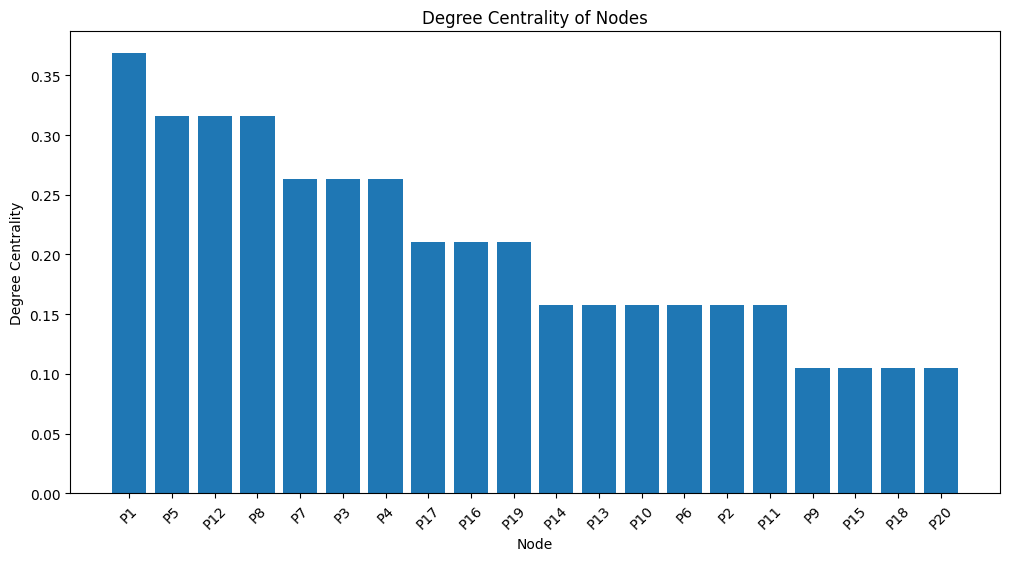

In [19]:
degree_plot = centrality_df.sort_values(
    "Degree Centrality",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    degree_plot["Node"],
    degree_plot["Degree Centrality"]
)

plt.xlabel("Node")
plt.ylabel("Degree Centrality")
plt.title("Degree Centrality of Nodes")

plt.xticks(rotation=45)

plt.show()

betweenness centrality graph

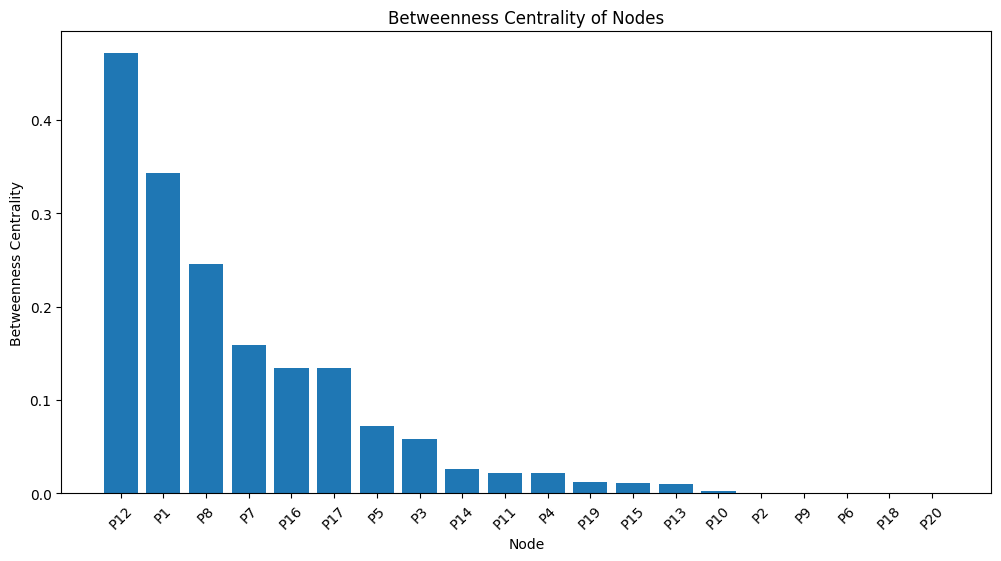

In [20]:
betweenness_plot = centrality_df.sort_values(
    "Betweenness Centrality",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    betweenness_plot["Node"],
    betweenness_plot["Betweenness Centrality"]
)

plt.xlabel("Node")
plt.ylabel("Betweenness Centrality")
plt.title("Betweenness Centrality of Nodes")

plt.xticks(rotation=45)

plt.show()

eigen vector centrality graph

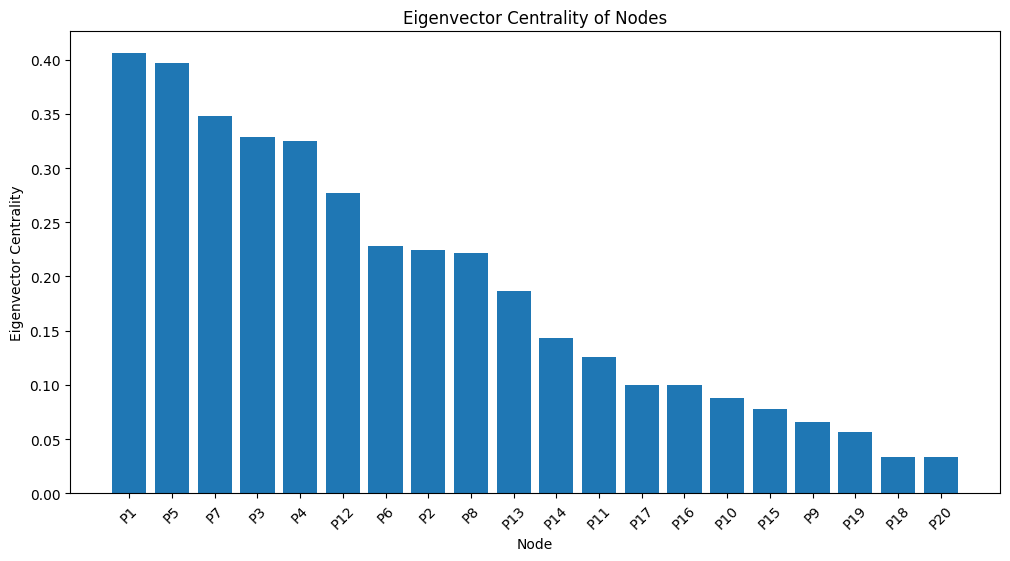

In [21]:
eigenvector_plot = centrality_df.sort_values(
    "Eigenvector Centrality",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    eigenvector_plot["Node"],
    eigenvector_plot["Eigenvector Centrality"]
)

plt.xlabel("Node")
plt.ylabel("Eigenvector Centrality")
plt.title("Eigenvector Centrality of Nodes")

plt.xticks(rotation=45)

plt.show()

In [22]:
centrality_df.to_csv(
    "centrality_results.csv",
    index=False
)

print("Centrality results saved successfully!")

Centrality results saved successfully!


Final Network Visualization Based on Degree

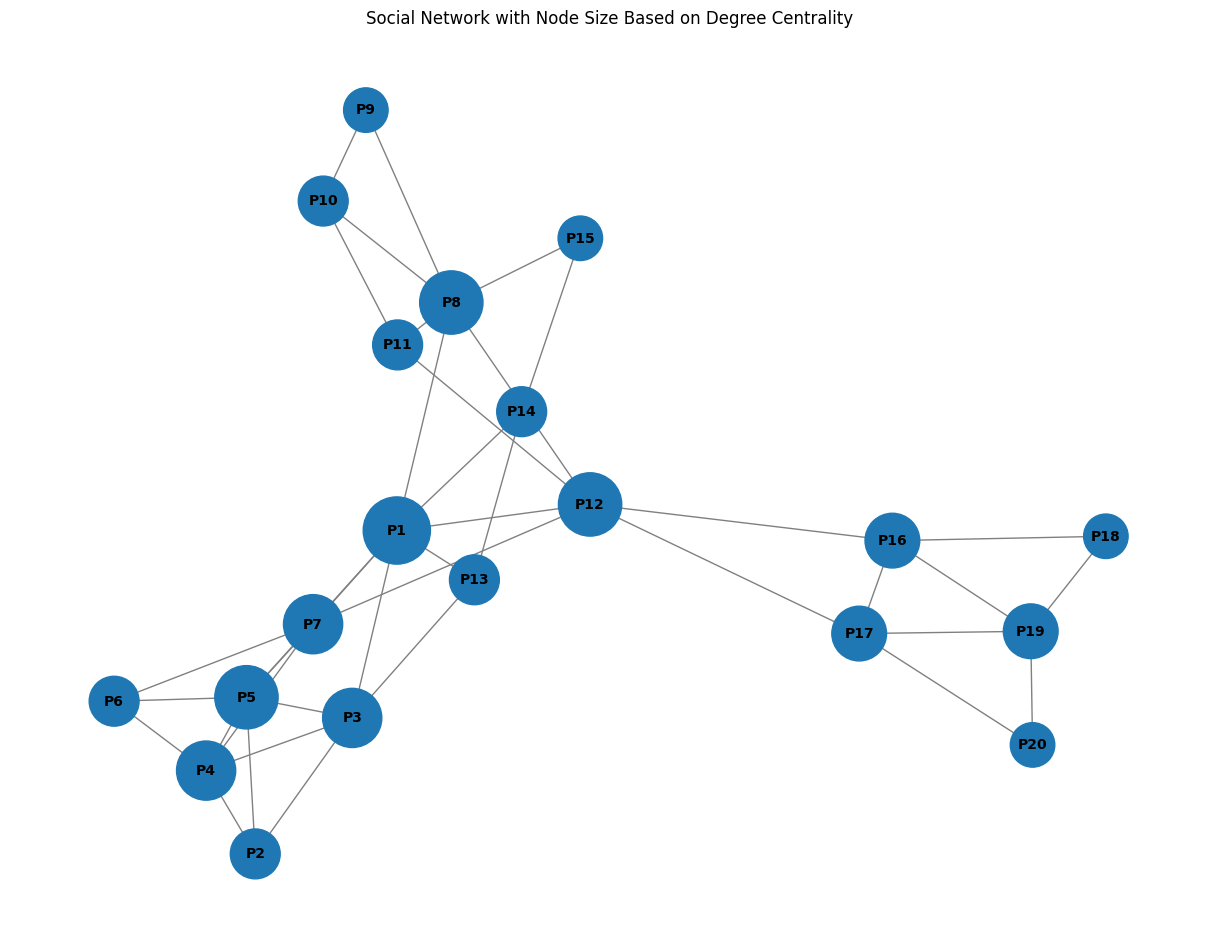

In [23]:
node_sizes = [
    5000 * degree_centrality[node] + 500
    for node in G.nodes()
]

plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Social Network with Node Size Based on Degree Centrality")

plt.show()

In [24]:
top_degree = centrality_df.sort_values(
    "Degree Centrality",
    ascending=False
).iloc[0]

top_betweenness = centrality_df.sort_values(
    "Betweenness Centrality",
    ascending=False
).iloc[0]

top_eigenvector = centrality_df.sort_values(
    "Eigenvector Centrality",
    ascending=False
).iloc[0]

print(
    f"{top_degree['Node']} has the highest degree centrality "
    f"({top_degree['Degree Centrality']})."
)

print(
    f"{top_betweenness['Node']} has the highest betweenness centrality "
    f"({top_betweenness['Betweenness Centrality']})."
)

print(
    f"{top_eigenvector['Node']} has the highest eigenvector centrality "
    f"({top_eigenvector['Eigenvector Centrality']})."
)

P1 has the highest degree centrality (0.3684210526315789).
P12 has the highest betweenness centrality (0.47110136452241713).
P1 has the highest eigenvector centrality (0.40577096806403407).
